In [1]:
field = 'F8'
zoi_maxradpc = 100

In [2]:
# Parameters
field = "SE"


In [3]:
# --- Imports ---
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

from astropy.io import fits
from astropy.stats import SigmaClip, sigma_clipped_stats
from astropy.convolution import Gaussian2DKernel
from photutils.background import Background2D, MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation import detect_sources, deblend_sources, SourceCatalog
from astropy.table import vstack, Table
from scipy.spatial import cKDTree
from collections import defaultdict


import os
import numpy as np
from collections import defaultdict
from scipy.spatial import cKDTree
from scipy.ndimage import map_coordinates


import json
import warnings
from time import perf_counter as clock

from scipy import ndimage
from scipy.ndimage import label as cc_label

warnings.filterwarnings('ignore')


# --- Config (edit these) ---
        # 'NW' | 'NE' | 'SW' | 'SE'
match_radius = 20   # pixels: association radius
pad = 20            # pixels: padding around zoom cutouts for saved plots

# --- ZOI physical pixel settings ---
       # max ZoI radius [pc]
galdistance  = 0.85      # Mpc
spatial_res  = 0.32      # arcsec/pix

# --- Output dirs ---
ZOI_MAP_DIR   = f'ZOI_maps/ZOI_map_{zoi_maxradpc}pc'
ZOI_PLOTS_DIR = f'plots/ZOI_plots_{zoi_maxradpc}pc'
os.makedirs(ZOI_MAP_DIR, exist_ok=True)
os.makedirs(ZOI_PLOTS_DIR, exist_ok=True)

# --- Folders ---
plots_dir = f'plots/peak_plots'
catalogs_dir = 'CATALOGS'   # per your spec, capitalized
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(catalogs_dir, exist_ok=True)


In [4]:
# --- File paths (edit if needed) ---
continuum_fits = f"../M33-maps/M33-{field}/M33{field}-SN3Continuum.fits"
halpha_fits    = f"../M33-maps/M33-{field}/M33-{field}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits"


# peaks_csv      = f"initial_peak_lists/{field}_peaks.csv"
peaks_csv     = f"final_peak_info/peaks_TH_field{field}_L15_snr6_bg30_std3_signoi3.csv"
if field == 'F5':
    peaks_csv = f"final_peak_info/peaks_TH_field{field}_L15_snr6_bg30_std3_signoi4p5.csv"
print("There are {} peaks in the input CSV file.".format(len(pd.read_csv(peaks_csv, comment='#'))))

# --- Load data ---
continuum_map = fits.getdata(continuum_fits)
halpha_map    = fits.getdata(halpha_fits)

ha_peaks = pd.read_csv(peaks_csv, comment='#')
if not {'x','y'}.issubset(ha_peaks.columns):
    raise ValueError("Peak list must contain 'x' and 'y' columns.")

ha_coords = np.vstack([ha_peaks['x'].values, ha_peaks['y'].values]).T

# Hα global LogNorm scaling helpers (for saved plots)
valid_pos = halpha_map[np.isfinite(halpha_map) & (halpha_map > 0)]
if valid_pos.size == 0:
    raise ValueError("Hα map has no positive finite values for LogNorm.")
vmin_global = np.nanpercentile(valid_pos, 5)
vmax_global = np.nanpercentile(valid_pos, 99)
if (not np.isfinite(vmin_global)) or (not np.isfinite(vmax_global)) or (vmax_global <= vmin_global):
    vmin_global, vmax_global = np.nanmin(valid_pos), np.nanmax(valid_pos)
    if not np.isfinite(vmin_global) or not np.isfinite(vmax_global) or vmax_global <= vmin_global:
        raise ValueError("Failed to compute valid global vmin/vmax for Hα.")

# Per-cutout LogNorm for saved plots
P_LO, P_HI = 3.0, 99.7
MIN_POS_PIX = 20
EPS_POS = np.nextafter(0, 1)

def local_lognorm(cutout, p_lo=P_LO, p_hi=P_HI, min_pos_pixels=MIN_POS_PIX):
    pos = cutout[np.isfinite(cutout) & (cutout > 0)]
    vmin_loc, vmax_loc = vmin_global, vmax_global
    if pos.size >= min_pos_pixels:
        lo = np.nanpercentile(pos, p_lo)
        hi = np.nanpercentile(pos, p_hi)
        if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
            vmin_loc, vmax_loc = lo, hi
    vmin_loc = max(vmin_loc, EPS_POS)
    if not np.isfinite(vmax_loc) or vmax_loc <= vmin_loc:
        vmax_loc = vmin_loc * 1.01
    return LogNorm(vmin=vmin_loc, vmax=vmax_loc)


There are 784 peaks in the input CSV file.


In [5]:
# Parameters for saddle-based merging
saddle_max_dist = 30.0      # max distance [pix] between peaks to consider
saddle_threshold = 0.9      # R = I_saddle / min(I_A, I_B) above which we MERGE
profile_npts = 100         # samples along the line between peaks

# Directory for peak-removal diagnostic plots
peak_removal_dir = os.path.join(plots_dir, "peak-removal-plots")
os.makedirs(peak_removal_dir, exist_ok=True)

# Start from continuum-combined peaks
peaks_df = ha_peaks.copy()
peaks_df["removed_by_saddle"] = False
peaks_df["removed_by_edge"] = False  # will be set in later cell

coords = peaks_df[["x", "y"]].values  # (N, 2)

ny, nx = halpha_map.shape  # already defined above, but just to be sure


def sample_line_intensity(x1, y1, x2, y2, image, npts=100):
    """Sample intensities along straight line between (x1,y1) and (x2,y2)."""
    xs = np.linspace(x1, x2, npts)
    ys = np.linspace(y1, y2, npts)
    # map_coordinates expects (row, col) = (y, x)
    vals = map_coordinates(image, [ys, xs], order=1, mode="nearest")
    return vals


def peak_intensity(x, y, image):
    """Get image intensity at (x, y) with safe integer indexing."""
    ix = int(round(x))
    iy = int(round(y))
    ix = np.clip(ix, 0, image.shape[1] - 1)
    iy = np.clip(iy, 0, image.shape[0] - 1)
    return float(image[iy, ix])


# Build neighbor list using KDTree (peaks within saddle_max_dist)
tree = cKDTree(coords)
neighbors = tree.query_ball_tree(tree, r=saddle_max_dist)

# Union-find structure for merging peaks
parent = np.arange(len(peaks_df))


def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i


def union(i, j):
    ri, rj = find(i), find(j)
    if ri != rj:
        parent[rj] = ri

def _clip_box(xmin, xmax, ymin, ymax, nx, ny):
    xmin = int(max(0, xmin)); xmax = int(min(nx, xmax))
    ymin = int(max(0, ymin)); ymax = int(min(ny, ymax))
    return xmin, xmax, ymin, ymax

# Decide merges based on saddle ratio R = I_saddle / min(I_A, I_B)
for i in range(len(peaks_df)):
    for j in neighbors[i]:
        if j <= i:
            continue
        x1, y1 = coords[i]
        x2, y2 = coords[j]

        prof = sample_line_intensity(x1, y1, x2, y2, halpha_map, npts=profile_npts)
        I_A = peak_intensity(x1, y1, halpha_map)
        I_B = peak_intensity(x2, y2, halpha_map)
        I_saddle = np.min(prof)
        I_min_peak = min(I_A, I_B)

        if I_min_peak <= 0:
            continue

        R = I_saddle / I_min_peak

        # If saddle is shallow, treat as one region and merge
        if R > saddle_threshold:
            union(i, j)

# Group indices by connected component (merged groups)
groups = defaultdict(list)
for i in range(len(peaks_df)):
    root = find(i)
    groups[root].append(i)

# For each group with >1 peak, keep brightest and mark others as removed_by_saddle
removed_indices_saddle = []
for root, idx_list in groups.items():
    if len(idx_list) <= 1:
        continue

    # choose brightest peak in Hα
    best_idx = max(
        idx_list,
        key=lambda k: peak_intensity(
            peaks_df.loc[k, "x"], peaks_df.loc[k, "y"], halpha_map
        ),
    )

    for k in idx_list:
        if k == best_idx:
            continue
        peaks_df.loc[k, "removed_by_saddle"] = True
        removed_indices_saddle.append(k)

print(f"Saddle-based merging removed {len(removed_indices_saddle)} peaks.")

# Diagnostic plots for each peak removed by the saddle method
pad = 25  # half-size of cutout in pixels

for k in removed_indices_saddle:
    x0 = peaks_df.loc[k, "x"]
    y0 = peaks_df.loc[k, "y"]

    xmin = int(np.floor(x0 - pad))
    xmax = int(np.ceil(x0 + pad))
    ymin = int(np.floor(y0 - pad))
    ymax = int(np.ceil(y0 + pad))
    xmin, xmax, ymin, ymax = _clip_box(xmin, xmax, ymin, ymax, nx, ny)

    cut = halpha_map[ymin:ymax, xmin:xmax]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(
        cut,
        origin="lower",
        cmap="magma",
        norm=local_lognorm(cut),
        extent=(xmin, xmax, ymin, ymax),
        aspect="equal",
    )

    # all peaks in this cutout
    in_box = (peaks_df["x"].between(xmin, xmax)) & (
        peaks_df["y"].between(ymin, ymax)
    )
    ax.scatter(
        peaks_df.loc[in_box, "x"],
        peaks_df.loc[in_box, "y"],
        marker="x",
        s=30,
        color="k",
        label="Nearby peaks",
    )

    # highlight removed peak
    ax.scatter(
        [x0],
        [y0],
        marker="o",
        s=60,
        facecolor="none",
        edgecolor="cyan",
        linewidth=1.8,
        label="Removed (saddle)",
    )

    ax.set_title(f"Peak {k} removed by saddle merging")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=7, loc="upper right")
    ax.tick_params(axis="both", which="both", labelsize=8)

    out_path = os.path.join(
        peak_removal_dir, f"{field}_peak{k}_removed_saddle.png"
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

print(f"Saddle removal diagnostic plots saved to: {peak_removal_dir}")


Saddle-based merging removed 48 peaks.


Saddle removal diagnostic plots saved to: plots/peak_plots/peak-removal-plots


In [6]:
# plot the final retained and original peaks for visual check
final_peaks = peaks_df[~peaks_df["removed_by_saddle"] & ~peaks_df["removed_by_edge"]]
final_peaks['kind'] = 'peak'
#save the final peaks catalog for later use
final_peaks.to_csv(f"{catalogs_dir}/final_peaks_{field}.csv", index=False)
print(f"Final retained peaks after ZOI processing: {len(final_peaks)}")
plt.figure(figsize=(20, 20))
plt.imshow(halpha_map, origin="lower", norm=local_lognorm(halpha_map))
plt.scatter(final_peaks["x"], final_peaks["y"], marker="o", s=15, color="r", label="Retained peaks", alpha = 0.7)
plt.scatter(peaks_df["x"], peaks_df["y"], marker="o", s=30, facecolor="none", edgecolor="k", label="Original peaks")
plt.title(f"Final retained peaks after ZOI processing")
plt.legend(fontsize=8)
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.savefig(f"{plots_dir}/final_retained_peaks_{field}.png", dpi=200)
plt.close()
print(f'Saved to {plots_dir}')

Final retained peaks after ZOI processing: 736


Saved to plots/peak_plots


In [7]:
warnings.filterwarnings('ignore')


sizebox = 1   # 1=3x3, 2=5x5, 3=7x7, etc. (for saved plots)

# --- Region of interest (avoid edges by ~50 px unless you set explicitly) ---
# ny, nx = halpha_map.shape
# xi, xf = 50, max(50, nx-50)
# yi, yf = 50, max(50, ny-50)
xi,xf,yi,yf = np.loadtxt(f'peak_files/param_sections/param_section_{sizebox}_{field}.txt', unpack=True)
#convert to int
xi,xf,yi,yf = int(xi), int(xf), int(yi), int(yf)

# --- Choose the map that provides the "A" (amplitude) weight at peaks ---
# If you have a preprocessed amplitude map (e.g., with stars masked), point to it here:
amp3_path = f'peak_files/data_for_visualisation_OIII+Ha_{field}/M33_{field}_HaOIII_amp_nonan.fits'   # change if needed

# /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/peak_files/data_for_visualisation_OIII+Ha_NW

if os.path.exists(amp3_path):
    amp_map, header_info = fits.getdata(amp3_path, header=True)
    print(f"Using amplitude map for ZOI weights: {amp3_path}")
else:
    amp_map = halpha_map
    header_info = None
    print("Amplitude map not found; using halpha_map as weights for ZOI.")

# ZOI-0) Use the *combined* peaks (final deduplicated set)

# If you already have new_peaks_df in memory from earlier cells, this will reuse it.
# Otherwise, load it from disk.
new_catalog_path = f"{catalogs_dir}/final_peaks_{field}.csv"
# if 'new_peaks_df' not in globals():
new_peaks_df = final_peaks.copy()
print("Loaded:", new_catalog_path)


# Sanity: ensure expected columns exist
required_cols = {'x', 'y'}
missing = required_cols - set(new_peaks_df.columns)
if missing:
    raise ValueError(f"new_peaks catalog missing columns: {missing}")

# Use the positions from the *combined* catalog (both singletons and continuum-centered replacements).
# If you ever want ONLY the continuum-centered replacements, uncomment the filter line.
use_df = new_peaks_df.copy()
# use_df = new_peaks_df[new_peaks_df['combined'] == True].copy()  # <- only continuum-centered entries

# Integer pixel coords for ZOI algorithm
xpic = use_df['x'].round().astype(int).to_numpy()
ypic = use_df['y'].round().astype(int).to_numpy()
npic = len(xpic)

# print(f"ZOI will use {npic} peaks from the combined catalog "
#       f"({use_df['combined'].sum()} combined=True, {npic - use_df['combined'].sum()} combined=False).")


# convert to pixels; +1 to be inclusive
zoi_maxradpi = int(zoi_maxradpc / (galdistance * 1e6 * np.tan(np.radians(spatial_res/3600)))) + 1
print(f"Galaxy distance = {galdistance} Mpc")
print(f"Spatial resolution = {spatial_res} arcsec/pix")
print(f"Max ZoI radius = {zoi_maxradpc} pc ≈ {zoi_maxradpi} pix")

# --- influence exponent (A / r^EXP) ---
INFLUENCE_EXP = 2.0

# --- clamp ROI to the array bounds in case images are small ---
xi = int(max(0, min(xi, nx-1))); xf = int(max(xi+1, min(xf, nx)))
yi = int(max(0, min(yi, ny-1))); yf = int(max(yi+1, min(yf, ny)))
print('Image portion studied xy = ', xi, xf, yi, yf)


Using amplitude map for ZOI weights: peak_files/data_for_visualisation_OIII+Ha_SE/M33_SE_HaOIII_amp_nonan.fits
Loaded: CATALOGS/final_peaks_SE.csv
Galaxy distance = 0.85 Mpc
Spatial resolution = 0.32 arcsec/pix
Max ZoI radius = 100 pc ≈ 76 pix
Image portion studied xy =  50 2000 50 2000


In [8]:
# Uses globals from previous cells:
# amp_map, header_info, xpic, ypic, npic, xi, xf, yi, yf, zoi_maxradpi, INFLUENCE_EXP, field
# And output dirs: ZOI_MAP_DIR

def makezoi_legacy(infile, exponent=2.0, roi=None, rmax_px=50, filep='ZoI_map'):
    """
    Reproduces the original double-loop algorithm:
    For each pixel (i,j) in ROI, among peaks within rmax_px, assign the peak that maximizes A_peak / r^exponent.
    Then remove disconnected components per peak, keeping only the component that contains the peak.
    Saves the cleaned ZOI FITS and returns the cleaned label map.
    """
    if roi is None:
        raise ValueError("ROI must be provided as (xi, xf, yi, yf)")

    xi, xf, yi, yf = roi
    h, w = infile.shape

    # 1) ZOI with all disconnected components
    print('1) Calculating ZoI (legacy, per-pixel A/r^exp)…')
    zoi_all = np.zeros_like(infile, dtype=float) / 0.0  # all NaN
    t0 = clock()

    # sample amplitude at peaks once
    A_peaks = np.nan_to_num(infile[ypic, xpic], nan=0.0, posinf=0.0, neginf=0.0)

    for i in range(xi, xf):
        # precompute dx to all peaks for this column
        distx = (xpic - i)
        for j in range(yi, yf):
            # skip invalid background pixels (match original behavior)
            if infile[j, i] == 0 or not np.isfinite(infile[j, i]):
                continue

            disty = (ypic - j)
            dist  = np.sqrt(distx*distx + disty*disty)
            k     = np.where(dist < rmax_px)[0]  # indices of nearby peaks

            if k.size == 0:
                continue

            # influence = A_peak / r^exponent (avoid r=0 issues)
            r = np.maximum(dist[k], 1e-6)
            ampdist = A_peaks[k] / np.power(r, exponent)
            if ampdist.size == 0:
                continue

            # choose winning peak index (0-based in k), store its global index (still 0-based)
            win_local = int(np.argmax(np.nan_to_num(ampdist)))
            win_peak  = int(k[win_local])
            zoi_all[j, i] = float(win_peak)  # temporary label 0..N-1

        # (optional) light progress
        if (i - xi) % 200 == 0:
            print(f'   column {i-xi}/{xf-xi}…')

    # make labels start at 1..N, leave NaNs as NaN
    valid = np.isfinite(zoi_all)
    zoi_all[valid] = zoi_all[valid] + 1.0
    print(f'   Time to calculate ZoI: {clock()-t0:.2f} s')

    # 2) Remove disconnected components (keep only the piece that contains the peak)
    print('2) Removing disconnected components (legacy)…')
    t1 = clock()
    zoi_clean = np.zeros_like(zoi_all, dtype=float)

    for ipeak in range(npic):
        L = float(ipeak + 1)  # label for this peak
        ry, rx = np.where(zoi_all == L)
        if ry.size == 0:
            continue

        # tight sub-image
        y0, y1 = max(ry.min()-1, 0), min(ry.max()+2, h)
        x0, x1 = max(rx.min()-1, 0), min(rx.max()+2, w)
        reg = np.copy(zoi_all[y0:y1, x0:x1])

        # zero out everything not this label
        reg[(reg != L)] = 0.0
        mask = (reg == L)

        lab, ncomp = cc_label(mask.astype(np.uint8))
        if ncomp <= 1:
            zoi_clean[y0:y1, x0:x1] = np.where(mask, L, zoi_clean[y0:y1, x0:x1])
        else:
            py = int(ypic[ipeak]) - y0
            px = int(xpic[ipeak]) - x0
            if py < 0 or px < 0 or py >= lab.shape[0] or px >= lab.shape[1]:
                # fallback: keep largest component
                comp_sizes = ndimage.sum(mask, lab, index=np.arange(1, ncomp+1))
                keep_comp = int(np.argmax(comp_sizes) + 1)
            else:
                keep_comp = int(lab[py, px])
            keep = (lab == keep_comp)
            zoi_clean[y0:y1, x0:x1] = np.where(keep, L, zoi_clean[y0:y1, x0:x1])

    zoi_clean[zoi_clean == 0] = np.nan
    print(f'   Time to remove disjoint components: {clock()-t1:.2f} s')

    # Save FITS
    zoi_fits_path = f"{ZOI_MAP_DIR}/{filep}_{field}.fits"
    if header_info is not None:
        fits.writeto(zoi_fits_path, zoi_clean, header_info, overwrite=True)
    else:
        fits.writeto(zoi_fits_path, zoi_clean, overwrite=True)
    print('   Saved ZOI map:', zoi_fits_path)

    return zoi_clean

def make_contours_legacy(zoi_labels, filep='ContZoI_map'):
    """
    Matches your original: XOR with a 1-pixel erosion (square footprint),
    return NaN background with 1 on edges; also saves FITS.
    """
    h, w = zoi_labels.shape
    outfile = np.zeros((h, w), dtype=float)

    for ipeak in range(npic):
        L = float(ipeak + 1)
        cy, cx = np.where(zoi_labels == L)
        if cy.size == 0:
            continue

        y0, y1 = max(cy.min()-1, 0), min(cy.max()+2, h)
        x0, x1 = max(cx.min()-1, 0), min(cx.max()+2, w)

        reg = np.copy(zoi_labels[y0:y1, x0:x1])
        reg[reg != L] = 0.0
        mask = (reg == L)

        # edge by XOR with erosion (square 3x3, like your original)
        edge = np.logical_xor(mask, ndimage.binary_erosion(mask))
        cont = np.zeros_like(reg, dtype=float)
        cont[edge] = L + 1.0  # any nonzero marker

        # accumulate 
        outfile[y0:y1, x0:x1] = np.where(cont > 0, 1.0, outfile[y0:y1, x0:x1])

    outfile[outfile == 0] = np.nan

    cont_fits_path = f"{ZOI_MAP_DIR}/{filep}_{field}.fits"
    if header_info is not None:
        fits.writeto(cont_fits_path, outfile, header_info, overwrite=True)
    else:
        fits.writeto(cont_fits_path, outfile, overwrite=True)
    print('   Saved ZOI contours:', cont_fits_path)

    return outfile


In [9]:
print(f"[CHECKPOINT] making ZoI map (~1 min)", flush=True)

roi = (xi, xf, yi, yf)
print(f'Computing legacy ZOI over ROI {roi} with r_max={zoi_maxradpi}px and exponent={INFLUENCE_EXP}…')

zoi_map = makezoi_legacy(
    infile=amp_map,
    exponent=INFLUENCE_EXP,
    roi=roi,
    rmax_px=zoi_maxradpi,
    filep='ZoI_map'
)

cont_map = make_contours_legacy(zoi_map, filep='ContZoI_map')
print('Legacy ZOI complete.')


[CHECKPOINT] making ZoI map (~1 min)


Computing legacy ZOI over ROI (50, 2000, 50, 2000) with r_max=76px and exponent=2.0…
1) Calculating ZoI (legacy, per-pixel A/r^exp)…
   column 0/1950…


   column 200/1950…


   column 400/1950…


   column 600/1950…


...

   column 1600/1950…


   column 1800/1950…


   Time to calculate ZoI: 28.72 s
2) Removing disconnected components (legacy)…


   Time to remove disjoint components: 6.05 s
   Saved ZOI map: ZOI_maps/ZOI_map_100pc/ZoI_map_SE.fits


   Saved ZOI contours: ZOI_maps/ZOI_map_100pc/ContZoI_map_SE.fits
Legacy ZOI complete.


In [10]:
unique, counts = np.unique(zoi_map[np.isfinite(zoi_map)], return_counts=True)
zoi_sizes = dict(zip(unique.astype(int), counts))

#how many have size < 10 pixels?
small_zoi = {k: v for k, v in zoi_sizes.items() if v < 100}
print(f"Number of ZOI regions with size < 10 pixels: {len(small_zoi)}")

#average zoi size
avg_zoi_size = np.mean(list(zoi_sizes.values()))
print(f"Average ZOI size (in pixels): {avg_zoi_size:.2f}")

Number of ZOI regions with size < 10 pixels: 18
Average ZOI size (in pixels): 2893.74


Saved field ZOI plot with colorbar: plots/ZOI_plots_100pc/ZOI_contours_SE.png


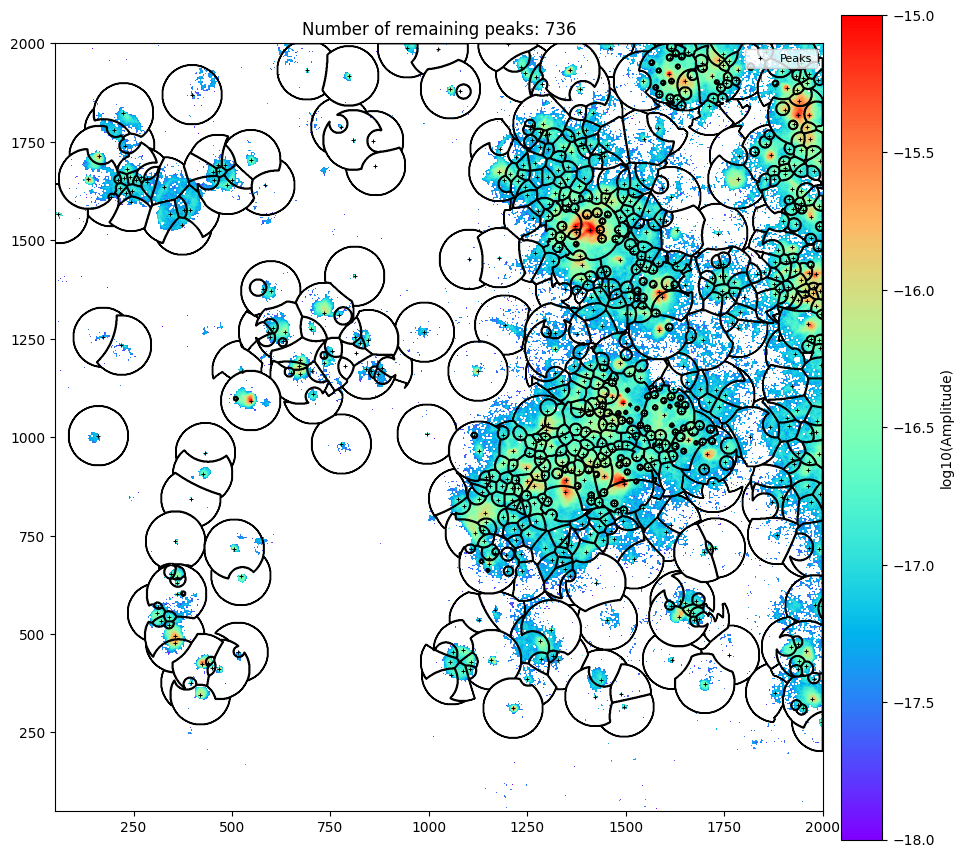

In [11]:
# ZOI-4) Save a per-field overlay plot (rainbow bg, black ZOI, labeled peaks, + colorbar)

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# choose the background (amplitude map preferred)
bg = np.copy(amp_map) if 'amp_map' in globals() else np.copy(halpha_map)

# log scale for visibility
bg_log = np.copy(bg)
bg_log[~np.isfinite(bg_log)] = np.nan
# avoid log(0)
bg_log = np.log10(np.maximum(bg_log, np.nanpercentile(bg_log[np.isfinite(bg_log)], 0.1)))

vmin = -18
vmax = -15
fig, ax = plt.subplots(figsize=(10, 10))

# show rainbow background + colorbar
im = ax.imshow(bg_log, origin='lower', cmap='rainbow', vmin=vmin, vmax=vmax, zorder=0)
cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('log10(Amplitude)', fontsize=10)

# plot peaks and text labels
ax.scatter(xpic, ypic, s=12, color='k', marker='+', lw=0.7, zorder=2, label='Peaks')
# for idx, (xp, yp) in enumerate(zip(xpic, ypic)):
#     ax.text(
#         xp + 3, yp + 3, str(idx),
#         fontsize=6, color='k', ha='left', va='bottom', zorder=3,
#         path_effects=[pe.withStroke(linewidth=1.5, foreground='white')]
#     )

# draw ZOI contours (blac k)
if np.isfinite(cont_map).any():
    edge = np.nan_to_num(cont_map, nan=0.0)
    ax.contour(edge, levels=[0.5], colors='k', linewidths=1.0, origin='lower', zorder=1)

#plot where the regions with small ZoI are
# plt.scatter(xpic[counts<100], ypic[counts<100], s=10, color='r', marker='o', facecolor='red', label='Small ZoI (<100 pix)', zorder=4)

ax.set_xlim(xi, xf)
ax.set_ylim(yi, yf)
ax.set_title(f'ZOI contours - field {field}', fontsize=12)
ax.legend(loc='upper right', fontsize=8)
plt.title("Number of remaining peaks: {}".format(len(xpic)))
out_plot = f"{ZOI_PLOTS_DIR}/ZOI_contours_{field}.png"
plt.tight_layout()
plt.savefig(out_plot, dpi=300, bbox_inches='tight')
# plt.close()

print("Saved field ZOI plot with colorbar:", out_plot)


In [12]:
xpic[counts<20]

array([1510])